In [1]:
from statsmodels.tsa.api import SimpleExpSmoothing,Holt,ExponentialSmoothing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error as rmse
import os
from ipywidgets import interact
from ipywidgets import widgets
%matplotlib inline
from IPython.display import clear_output,display
os.chdir("C:/Users/PGCP-AI/ML/MachineLearning/Datasets")

In [3]:
df = pd.read_csv("monthly-beer-production-in-austr.csv")
df

,Month,Monthly beer production
0,1956-01,93.2
1,1956-02,96.0
2,1956-03,95.2
3,1956-04,77.1
4,1956-05,70.9
...,...,...
471,1995-04,127.0
472,1995-05,151.0
473,1995-06,130.0
474,1995-07,119.0


In [4]:
y_train = df['Monthly beer production'][:-12]
y_test = df['Monthly beer production'][-12:]

# Simple Exponential Smoothing

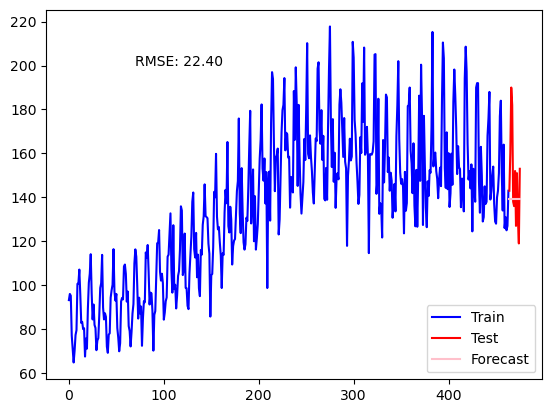

In [6]:
alpha = 0.2 
ses = SimpleExpSmoothing(y_train)
fit = ses.fit(smoothing_level=alpha,optimized=False)
fcast1 = fit.forecast(len(y_test))
y_train.plot(c='blue',label='Train')
y_test.plot(c='red',label='Test')
rms = rmse(y_test,fcast1)
plt.text(70,200,f"RMSE: {rms:.2f}")
fcast1.plot(c='pink',label='Forecast')
plt.legend(loc='best')
plt.show()

In [13]:
def ses_smooth(alpha):
    clear_output(wait=True)
    plt.figure(figsize=(8,6))
    alpha = alpha
    ses = SimpleExpSmoothing(y_train)
    fit = ses.fit(smoothing_level=alpha,optimized=False)
    fcast1 = fit.forecast(len(y_test))
    y_train.plot(c='blue',label='Train')
    y_test.plot(c='orange',label='Test')
    rms = rmse(y_test,fcast1)
    plt.text(70,200,f"RMSE: {rms:.2f}")
    # rms = np.round(rmse(y_test, fcast1), 2)
    # plt.text(100,600,f"RMSE: {rms}")
    fcast1.plot(c='green',label='Forecast')
    plt.title(f"Simple Exponential Smoothing (Alpha={alpha:.3f})")
    plt.legend(loc='best')
    plt.show()
interact(ses_smooth,alpha=widgets.FloatSlider(value=0.2,min=0.001,max=1,step=0.001))


interactive(children=(FloatSlider(value=0.2, description='alpha', max=1.0, min=0.001, step=0.001), Output()), …

<function __main__.ses_smooth(alpha)>

In [14]:
def holt_smooth(a,b):
    clear_output(wait=True)
    plt.figure(figsize=(8,6))
    alpha,beta = a,b
    clear_output(wait=True)
    plt.figure(figsize=(8,6))
    alpha = alpha
    holt = Holt(y_train)
    fit = holt.fit(smoothing_level=alpha,smoothing_trend=beta,optimized=False)
    fcast1 = fit.forecast(len(y_test))
    y_train.plot(c='blue',label='Train')
    y_test.plot(c='orange',label='Test')
    rms = rmse(y_test,fcast1)
    plt.text(70,200,f"RMSE: {rms:.2f}")
    # rms = np.round(rmse(y_test, fcast1), 2)
    # plt.text(100,600,f"RMSE: {rms}")
    fcast1.plot(c='green',label='Forecast')
    plt.title(f"Holt Smoothing (Alpha={alpha:.3f}),(Beta={beta:.3f})")
    plt.legend(loc='best')
    plt.show()
interact(holt_smooth,a=widgets.FloatSlider(value=0.2,min=0.001,max=1,step=0.001),b=widgets.FloatSlider(value=0.2,min=0.001,max=1,step=0.001))


interactive(children=(FloatSlider(value=0.2, description='a', max=1.0, min=0.001, step=0.001), FloatSlider(val…

<function __main__.holt_smooth(a, b)>

# Holt's Exponential Smoothing Without Alpha and Beta  

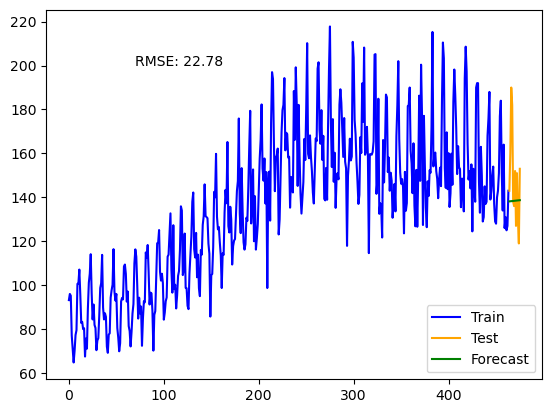

{'smoothing_level': np.float64(0.693531718584702),
 'smoothing_trend': np.float64(0.006734598751291242),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(93.2),
 'initial_trend': np.float64(2.799999999999997),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [15]:
holt = Holt(y_train)
fit = holt.fit(optimized=True)
fcast1 = fit.forecast(len(y_test))
y_train.plot(c='blue',label='Train')
y_test.plot(c='orange',label='Test')
rms = rmse(y_test,fcast1)
plt.text(70,200,f"RMSE: {rms:.2f}")
# rms = np.round(rmse(y_test, fcast1), 2)
# plt.text(100,600,f"RMSE: {rms}")
fcast1.plot(c='green',label='Forecast')
plt.legend(loc='best')
plt.show()
holt.params

# Exponential Smoothing (Holt Winter)

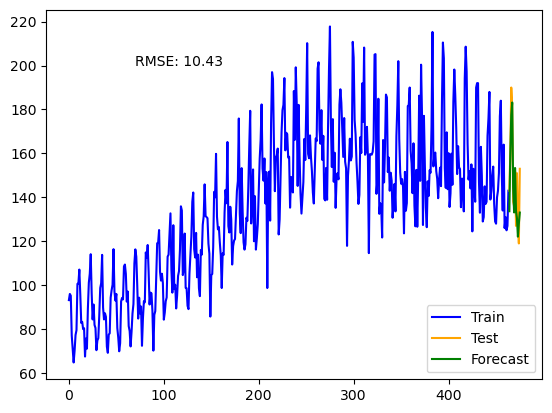

In [20]:
alpha,beta,gamma=0.2,0.03,0.4
hw = ExponentialSmoothing(y_train,seasonal_periods=12,trend='add',seasonal='add')
fit = hw.fit(smoothing_level=alpha,smoothing_trend=beta,smoothing_seasonal=gamma,optimized=False)
fcast1 = fit.forecast(len(y_test))
y_train.plot(c='blue',label='Train')
y_test.plot(c='orange',label='Test')
rms = rmse(y_test,fcast1)
plt.text(70,200,f"RMSE: {rms:.2f}")
# rms = np.round(rmse(y_test, fcast1), 2)
# plt.text(100,600,f"RMSE: {rms}")
fcast1.plot(c='green',label='Forecast')
plt.legend(loc='best')
plt.show()

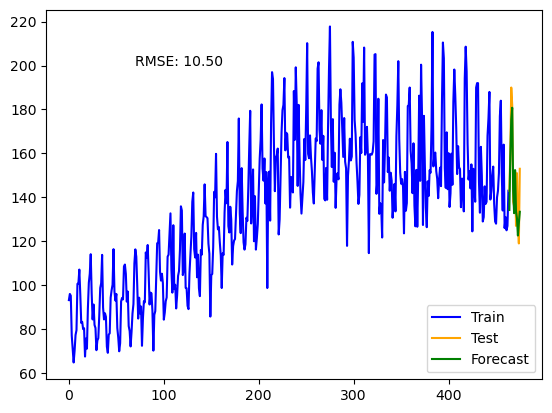

In [17]:
alpha,beta,gamma=0.2,0.03,0.4
hw = ExponentialSmoothing(y_train,seasonal_periods=12,trend='add',seasonal='mul')
fit = hw.fit(smoothing_level=alpha,smoothing_trend=beta,smoothing_seasonal=gamma,optimized=False)
fcast1 = fit.forecast(len(y_test))
y_train.plot(c='blue',label='Train')
y_test.plot(c='orange',label='Test')
rms = rmse(y_test,fcast1)
plt.text(70,200,f"RMSE: {rms:.2f}")
# rms = np.round(rmse(y_test, fcast1), 2)
# plt.text(100,600,f"RMSE: {rms}")
fcast1.plot(c='green',label='Forecast')
plt.legend(loc='best')
plt.show()

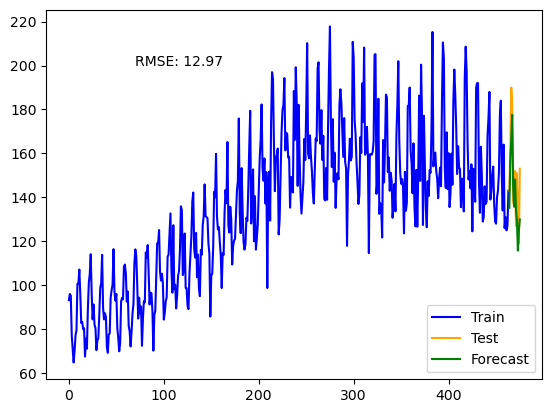

In [18]:
alpha,beta,gamma=0.2,0.03,0.4
hw = ExponentialSmoothing(y_train,seasonal_periods=12,trend='add',seasonal='mul')
fit = hw.fit(optimized=True)
fcast1 = fit.forecast(len(y_test))
y_train.plot(c='blue',label='Train')
y_test.plot(c='orange',label='Test')
rms = rmse(y_test,fcast1)
plt.text(70,200,f"RMSE: {rms:.2f}")
fcast1.plot(c='green',label='Forecast')
plt.legend(loc='best')
plt.show()